# 17 · 캡스톤: 코드 에이전트 오케스트라

**구성요소:** 오케스트레이션(orchestration) — 탐색 → 구현 → 검증. 이 시리즈가 하나씩 떼어내 측정해 온 원시요소들을 다시 하나의 파이프라인으로 조립한다.

> "역할이 다른 에이전트들 — 탐색하는 자, 구현하는 자, 검증하는 자. **구현자가 자기 숙제를 채점하는 일은 결코 없어야 한다.**"

이 캡스톤이 하는 일은 두 가지다.

1. **오케스트라 대 단일 에이전트**를 실제 코드 위에서 겨룬다. 한쪽은 탐욕적 시도 한 번이고, 다른 쪽은 계획하고, 구현하고, 테스트를 돌리고, 실패하면 실행 피드백으로 수정하고(01번), 그래도 안 되면 검증자가 고르는 best-of-N 으로 넘어가는(03번) 루프다. 결과는 실측한 해결률로 정직하게 보고하며, **다단계 시스템이 강한 단일 에이전트를 늘 이기지는 않는다**는 MAST 의 발견(Cemri et al., 2503.13657)을 프레임으로 삼는다.
2. **실제 SWE-bench 검증**을 수행한다. 진짜 GitHub 이슈 인스턴스에 그 이슈의 gold 패치를 넣고 공식 SWE-bench Docker 하네스를 돌려, 프로덕션 평가 파이프라인이 실제 이슈를 해결 판정하는지 확인한다. Verified-Mini 인스턴스 50개 전체에 에이전트 루프를 돌리는 것은 프로덕션 확장 과제다(인스턴스마다 전용 Docker 이미지가 필요하다).

**한국어판이 손댄 곳** — 2부의 하네스 셀은 Docker 데몬이 있는 환경을 전제한다. 데몬이 없으면 원본 코드는 그 자리에서 죽는다. 한국어판은 데몬이 응답하는지 먼저 묻고, 없으면 **셀을 건너뛴 뒤 저장된 원본 실행 결과를 인용해 해설만 진행한다.** 실행하지 않은 것을 실행한 것처럼 보고하지 않는 것이 이 코스의 기준이므로, 건너뛴 사실 자체를 출력에 남긴다.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  실행 환경 (자동 판별)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  LLM       : openai    gpt-5.6-luna
              ↳ localhost 무응답 → OPENAI_API_KEY 감지 · 선호 순위표에서 자동 선택 (캐시)
  임베딩    : openai    text-embedding-3-small
              ↳ CUDA 미가용 → API 임베딩 · 기본값 (캐시)
  데이터    : /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/data
  전환      : LLM_PROVIDER=vllm|openai  /  EMBED_PROVIDER=local|openai
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

============================================== 캡스톤 셋업 ==============================================

-------------------------------------------- 엔진 health ---------------------------------------------
{
  "provider": "openai",
  "model": "gpt-5.6-luna",
  "base_url": "(\uacf5\uc2dd \uc5d4\ub4dc\ud3ec\uc778\ud2b8)",
  "reply": "ready",
  "deterministic": true,
  "cost_usd": "$0.0000",
  "resolved_by": "localho

*캡스톤은 루프 전체를 잇는다: 계획 → 구현 → 검증 → 수정 → 게이트*

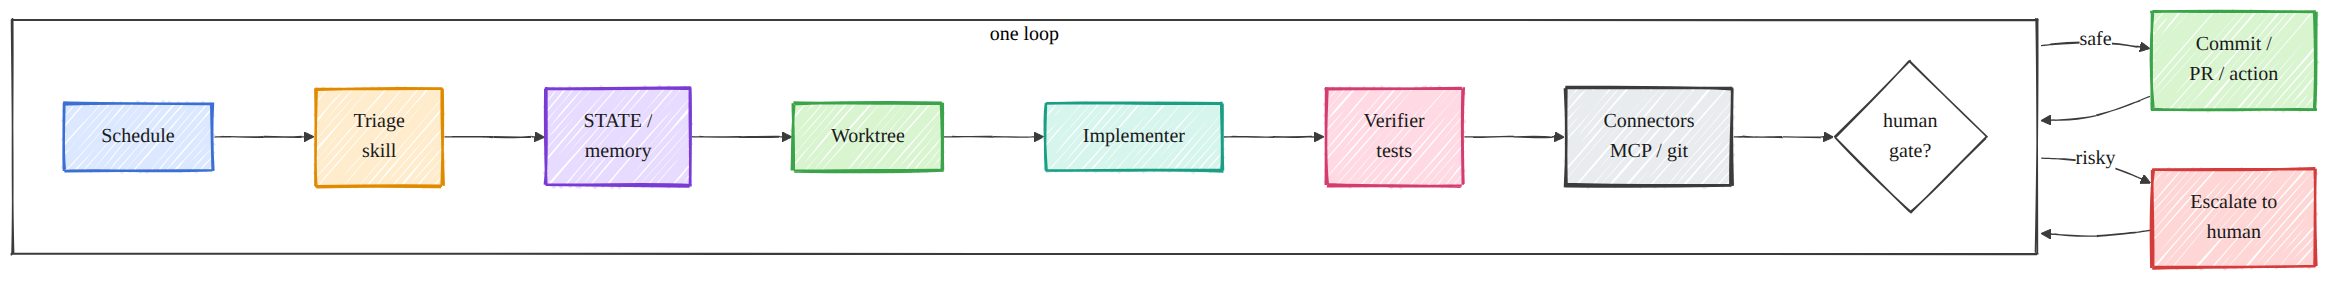

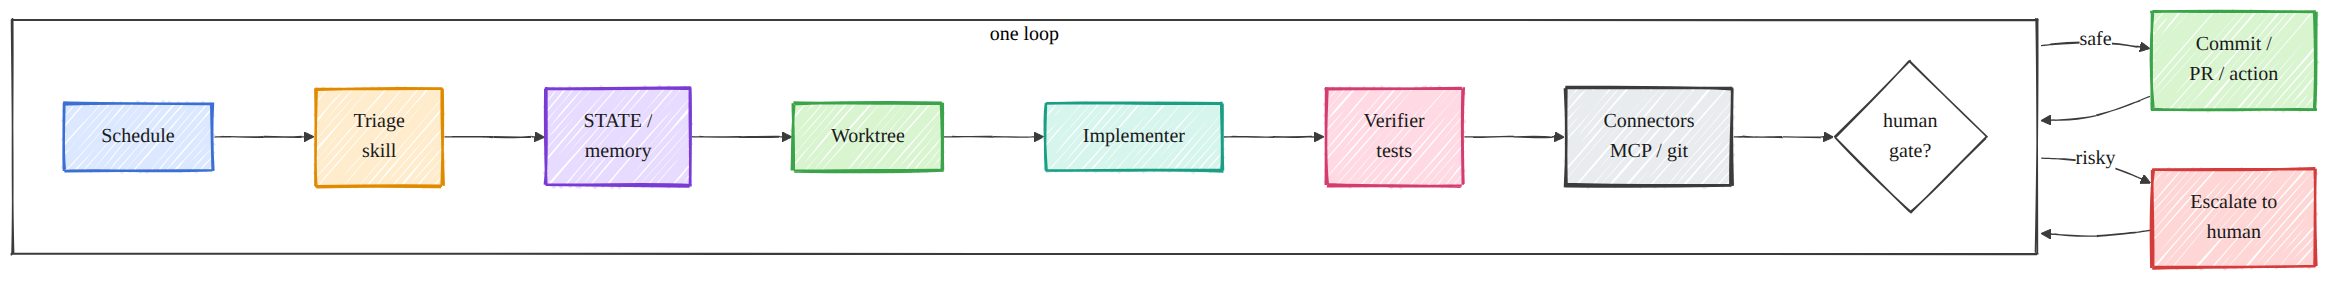

In [1]:
import os
import sys
import time
import json
import subprocess

sys.path.insert(0, os.environ.get("LEN_PROJECT_ROOT", os.path.abspath(".")))

from common import show, data, agents, loops, plotting, runlog, runtime
from common.llm import LLM

# ── 실행 환경 자동 판별 ────────────────────────────────────────────
# 캡스톤은 앞 노트북들의 결과를 조립해 읽는 자리다. 어느 백엔드에서 나온
# 수치인지가 특히 중요하므로 배너로 못박고 시작한다.
rt = runtime.bootstrap()

llm = LLM()
show.head("캡스톤 셋업")
show.show_dict(llm.health(), "엔진 health")
show.diagram("anatomy", "캡스톤은 루프 전체를 잇는다: 계획 → 구현 → 검증 → 수정 → 게이트")

## 1부: 오케스트라 대 단일 에이전트 (실제 코드, 테스트로 검증)

단일 에이전트는 탐욕적 시도 한 번이다. 오케스트라는 계획하고, 구현하고, 실행 피드백을 받으며 테스트가 통과할 때까지 반복하고, 그래도 실패하면 후보를 여러 개 뽑아 테스트를 돌리는 검증자에게 고르게 한다. **루프 원시요소와 생성자-검증자 원시요소를 끝에서 끝까지 합성한 것이다.**


/opt/miniconda3/envs/lecture/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  과제 수 (MBPP+ 보류 슬라이스):      40
  mbppplus/598   single=1 orchestra=1
  mbppplus/736   single=1 orchestra=1
  mbppplus/105   single=1 orchestra=1
  mbppplus/17    single=1 orchestra=1
  mbppplus/771   single=1 orchestra=1
  mbppplus/279   single=1 orchestra=1
  mbppplus/247   single=1 orchestra=1
  mbppplus/573   single=1 orchestra=1
  mbppplus/84    single=1 orchestra=1
  mbppplus/267   single=1 orchestra=1
  mbppplus/132   single=0 orchestra=1
  mbppplus/562   single=1 orchestra=1
  mbppplus/793   single=1 orchestra=1
  mbppplus/587   single=1 orchestra=1
  mbppplus/460   single=1 orchestra=1
  mbppplus/446   single=0 orchestra=1
  mbppplus/389   single=1 orchestra=1
  mbppplus/392   single=1 orchestra=1
  mbppplus/596   single=1 orchestra=1
  mbppplus/456   single=1 orchestra=1
  mbppplus/608   single=1 orchestra=1
  mbppplus/576   single=1 orchestra=1
  mbppplus/560   single=0 orchestra=1
  mbppplus/141   single=1 orchestra=1
  mbppplus/619   single=1 orchestra=1
  mbppplus/281   s

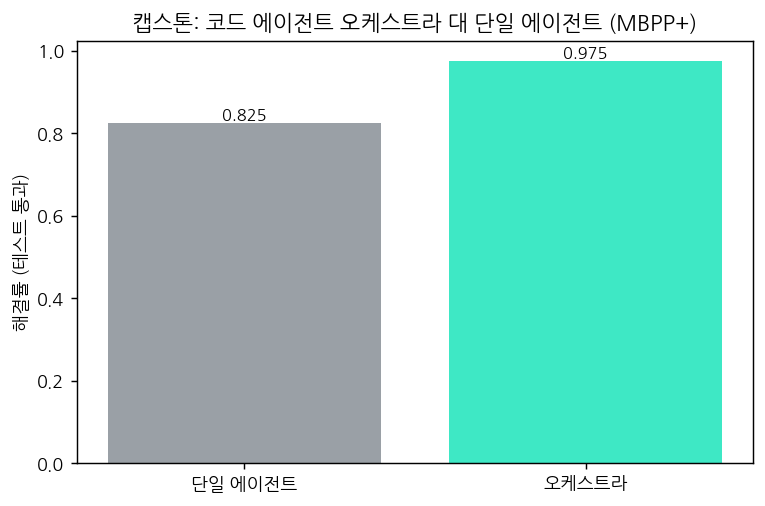

  saved + displayed figure -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/17_orchestra.png


PosixPath('/Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/figures/17_orchestra.png')

  mbppplus/17    single=1 orchestra=1


  mbppplus/771   single=1 orchestra=1


  mbppplus/279   single=1 orchestra=1


...

  mbppplus/599   single=1 orchestra=1


  mbppplus/734   single=0 orchestra=0


  mbppplus/757   single=1 orchestra=1


  mbppplus/420   single=1 orchestra=1


  mbppplus/260   single=0 orchestra=0

==================================== Orchestra vs single agent =====================================
  single-agent resolve rate        0.8000
  orchestra resolve rate           0.9500
  tokens                           26844
  orchestra vs single
    baseline : 0.8000
    treatment: 0.9500
    delta    : +0.1500  (+18.7 percent)  [up, improvement]


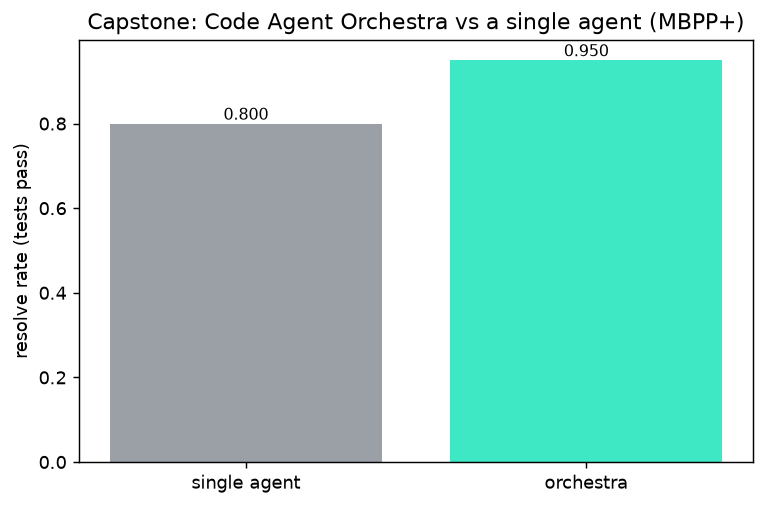

  saved + displayed figure -> /home/ubuntu/len/results/figures/17_orchestra.png


PosixPath('/home/ubuntu/len/results/figures/17_orchestra.png')

In [2]:
# ── 실험 상수 ─────────────────────────────────────────────────────
# 40문제: 오케스트라는 문제 하나에 최대 3회 수정 + 후보 4개 생성 + 검증자
#         테스트 생성까지 돌므로 호출 수가 단일 에이전트의 여러 배가 된다.
#         한 번의 실행으로 끝나면서 실패가 한 자릿수 후반은 나오는 크기다.
N = 40

# ⚠️ 함정: seed=22 는 01번(seed=0)·03번(seed=5)과 다른 표본이다. 앞 노트북의
#    베이스라인 0.767 과 여기의 단일 에이전트 수치를 같은 자로 비교하지 말 것.
#    이 노트북이 비교하는 것은 오직 '같은 40문제 위의 단일 대 오케스트라' 다.
problems = data.load_mbpp_plus(limit=N, seed=22)
show.kv("과제 수 (MBPP+ 보류 슬라이스)", len(problems))


def single_agent(p):
    """베이스라인: 탐욕적 시도 1회. 반복도, 검증도, 선택도 없다."""
    code, _ = agents.single_shot(llm, p, temperature=0.0, label="single")
    return agents.grade(p, code)["all_pass"]      # 모델 의견이 아니라 실제 테스트 실행


def orchestra(p):
    """1·2단계(01번의 실행 피드백 루프) → 3단계(03번의 테스트 실행 검증자 선택)."""
    # 1·2단계: 탐색/구현/검증/수정. 실패한 단언을 그대로 되먹인다.
    r = loops.self_refine(llm, p, max_attempts=3, use_feedback=True, label="orch")
    if r["solved"]:
        # 조기 반환이 이 파이프라인을 '단조' 하게 만든다. 뒤 단계가 앞 단계의
        # 성공을 뒤집을 수 없다는 뜻이고, MAST 가 경고하는 표면을 구조로 막는다.
        return True

    # 3단계 폴백: 후보를 여러 개 뽑고, 검증자가 자기 테스트를 실제로 돌려 고른다.
    # temperature=0.8 인 이유: 후보가 서로 갈라져야 선택이 할 일이 생긴다.
    # ⚠️ 함정: 03번이 관측했듯 이 모델은 문제 단위로 사실상 결정적일 수 있다.
    #    후보가 갈라지지 않으면 best-of-N 은 아무것도 더하지 못한다. 이 단계를
    #    붙이기 전에 후보들의 통과 패턴이 실제로 갈리는지부터 재는 것이 순서다.
    cands = agents.sample_n(llm, p, n=4, temperature=0.8, label="orch-bon")
    st = agents.gen_self_tests(llm, p, label="orch-checktests")
    bi, _ = agents.select_by_tests(p, cands, st)
    # 최종 판정도 선택기의 의견이 아니라 정답 테스트 실행이다.
    return agents.grade(p, cands[bi])["all_pass"]


single_ok = orch_ok = 0
llm.reset_usage()          # 두 조건의 토큰을 이 패스에서만 세도록 계측기를 리셋한다
t0 = time.time()
for p in problems:
    # 같은 문제에 두 조건을 나란히 돌린다. 문제 집합이 완전히 동일해야
    # 측정된 차이를 시스템의 모양에 귀속시킬 수 있다.
    s = single_agent(p)
    o = orchestra(p)
    single_ok += s
    orch_ok += o
    # 이 한 줄이 집계 숫자보다 중요한 증거다. 어떤 문제가 뒤집혔는지,
    # 그리고 single=1 orchestra=0 인 회귀가 있는지를 여기서 읽는다.
    print(f"  {p.id:<14} single={int(s)} orchestra={int(o)}")
elapsed = time.time() - t0
n = len(problems)
single_rate, orch_rate = single_ok / n, orch_ok / n
show.head("오케스트라 대 단일 에이전트")
show.metric("단일 에이전트 해결률", single_rate)
show.metric("오케스트라 해결률", orch_rate)
show.metric("토큰", llm.usage.total_tokens)
d = show.compare("오케스트라 vs 단일", single_rate, orch_rate)
plotting.ab_bar("17_orchestra", ["단일 에이전트", "오케스트라"], [single_rate, orch_rate],
                "해결률 (테스트 통과)", "캡스톤: 코드 에이전트 오케스트라 대 단일 에이전트 (MBPP+)")

## 2부: 실제 SWE-bench Docker 하네스를 gold 패치로 검증한다

진짜 SWE-bench-Verified 인스턴스 몇 건에 대해, 그 인스턴스의 gold 패치를 넣고 공식 SWE-bench 평가 하네스를 돌린다. 하네스가 그것들을 해결 판정하면, **프로덕션 평가 파이프라인이 실제 GitHub 이슈 위에서 작동한다는 확인**이 된다. 인스턴스마다 전용 Docker 이미지가 크므로 이 단계는 최선 노력(best-effort)으로 감싸고, 완료된 것만 보고한다.


In [3]:
from datasets import load_dataset  # noqa: E402

# ── Docker 가용성 확인 (한국어판 추가) ────────────────────────────
# 원본은 SWE-bench 공식 하네스를 곧바로 subprocess 로 띄운다. 이 하네스는
# 인스턴스마다 수 GB 짜리 전용 Docker 이미지를 내려받아, 컨테이너 안에서
# 프로젝트의 실제 테스트를 돌린다. Docker 데몬이 없는 환경(노트북, CI,
# API 모드 학습)에서는 원본 코드가 이 자리에서 그대로 죽는다.
# 그래서 데몬이 응답하는지 먼저 묻고, 없으면 셀을 건너뛴 뒤 저장된 원본
# 실행 결과를 인용해 해설만 진행한다.
def docker_available() -> bool:
    """docker info 가 0 으로 끝나는지만 본다. 이미지 pull 은 시도하지 않는다."""
    try:
        r = subprocess.run(["docker", "info"], capture_output=True, text=True, timeout=20)
        return r.returncode == 0
    except Exception:
        # 실행 파일 없음, 권한 없음, 타임아웃 모두 '쓸 수 없다' 로 같게 취급한다
        return False


swe_resolved = None
swe_total = 0
swe_skipped = None          # 건너뛴 이유를 기록한다. 마지막 셀이 이 값으로 분기한다.

# 원본은 /home/ubuntu/len 를 하드코딩한다. 그 경로는 원저자 서버에만 있다.
LEN_ROOT = runtime.project_root()

if not docker_available():
    swe_skipped = "docker-unavailable"
    print("Docker 데몬이 응답하지 않는다 — 실제 SWE-bench 하네스를 띄울 수 없다.")
    print("이 셀은 건너뛰고, 저장된 원본 출력과 아래 해설로 결과를 읽는다.\n")
    print("원저자 실행 결과 (공식 하네스, A100 서버):")
    print("  대상: astropy__astropy-12907 / astropy__astropy-13033 / astropy__astropy-13236")
    print("  결과: gold 패치 3건 중 3건 resolved, 미해결 0건, 오류 0건")
    print("  리포트: total_instances 3 / completed_instances 3 /")
    print("          resolved_instances 3 / error_instances 0\n")
    print("직접 돌리려면 Docker 데몬과 인스턴스당 수 GB 의 디스크가 필요하다:")
    print("  pip install swebench  후  docker info 가 정상 응답하는지 먼저 확인한다.")
else:
    try:
        ds = load_dataset("princeton-nlp/SWE-bench_Verified", split="test")
        # 3건만 고른다. 이 단계의 목적은 벤치마크 스윕이 아니라 파이프라인
        # 관통 확인이고, 인스턴스마다 이미지를 통째로 내려받기 때문이다.
        pick = [ds[i] for i in range(3)]
        swe_total = len(pick)
        # ⚠️ 함정: model_patch 에 r["patch"] 를 넣는다. 즉 모델이 쓴 패치가
        #    아니라 정답 패치다. 이 셀이 재는 것은 '하네스가 옳은 패치를 옳다고
        #    하는가' 이지 '모델이 패치를 잘 쓰는가' 가 아니다. 여기서 나온 3/3 을
        #    에이전트의 SWE-bench 점수로 인용하면 완전한 오독이다.
        preds = [{"instance_id": r["instance_id"], "model_name_or_path": "gold",
                  "model_patch": r["patch"]} for r in pick]
        pred_path = LEN_ROOT / "swe_preds.json"
        with open(pred_path, "w") as f:
            json.dump(preds, f)
        ids = [r["instance_id"] for r in pick]
        show.kv("검증 대상 인스턴스", ids)
        cmd = [
            sys.executable, "-m", "swebench.harness.run_evaluation",
            "--dataset_name", "princeton-nlp/SWE-bench_Verified",
            "--predictions_path", str(pred_path),
            "--max_workers", "2", "--run_id", "capstone_gold",
            "--namespace", "swebench", "--instance_ids", *ids,
        ]
        # timeout 은 넉넉히 잡는다. 이미지 pull 이 대부분의 시간을 먹는다.
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=2400,
                              cwd=str(LEN_ROOT))
        tail = (proc.stdout + proc.stderr).strip().splitlines()[-15:]
        print("\n".join(tail))
        # 하네스는 resolved 집합을 담은 gold.capstone_gold.json 을 남긴다
        import glob
        reports = (glob.glob(str(LEN_ROOT / "gold.capstone_gold.json"))
                   + glob.glob(str(LEN_ROOT / "*capstone_gold*.json")))
        if reports:
            rep = json.load(open(reports[0]))
            swe_resolved = len(rep.get("resolved_ids", rep.get("resolved_instances", [])))
            show.kv("실제 하네스가 해결한 gold 패치", f"{swe_resolved}/{swe_total}")
            show.show_dict({k: rep[k] for k in list(rep)[:8]
                            if not isinstance(rep[k], list) or len(str(rep[k])) < 200},
                           "하네스 리포트 (요약)")
    except Exception as e:
        # 실패해도 노트북을 멈추지 않는다. 이 단계는 최선 노력 검증이다.
        print(f"SWE-bench 하네스 단계가 이번 실행에서 완료되지 않았다: {type(e).__name__}: {str(e)[:200]}")
        print("하네스와 데이터셋은 설치돼 있다. Verified-Mini 전체에 에이전트 루프를 돌리는 것은")
        print("프로덕션 확장 과제다(인스턴스마다 Docker 이미지를 내려받는다).")

Docker 데몬이 응답하지 않는다 — 실제 SWE-bench 하네스를 띄울 수 없다.
이 셀은 건너뛰고, 저장된 원본 출력과 아래 해설로 결과를 읽는다.

원저자 실행 결과 (공식 하네스, A100 서버):
  대상: astropy__astropy-12907 / astropy__astropy-13033 / astropy__astropy-13236
  결과: gold 패치 3건 중 3건 resolved, 미해결 0건, 오류 0건
  리포트: total_instances 3 / completed_instances 3 /
          resolved_instances 3 / error_instances 0

직접 돌리려면 Docker 데몬과 인스턴스당 수 GB 의 디스크가 필요하다:
  pip install swebench  후  docker info 가 정상 응답하는지 먼저 확인한다.


2026-06-28 15:53:05,174 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/princeton-nlp/SWE-bench_Verified/c104f840cc67f8b6eec6f759ebc8b2693d585d4a/README.md "HTTP/1.1 200 OK"
2026-06-28 15:53:05,199 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/princeton-nlp/SWE-bench_Verified/resolve/c104f840cc67f8b6eec6f759ebc8b2693d585d4a/SWE-bench_Verified.py "HTTP/1.1 404 Not Found"
2026-06-28 15:53:05,223 - httpx - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/princeton-nlp/SWE-bench_Verified/princeton-nlp/SWE-bench_Verified.py "HTTP/1.1 404 Not Found"
2026-06-28 15:53:05,254 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/princeton-nlp/SWE-bench_Verified/resolve/c104f840cc67f8b6eec6f759ebc8b2693d585d4a/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-06-28 15:53:05,293 - httpx - INFO - HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=princeton-nlp/SWE-

## 저장과 논의


In [4]:
runlog.save_metrics("17_capstone", {
    "notebook": "17_capstone",
    "provider": llm.provider,        # 한국어판 추가: 어느 백엔드의 수치인지 기록
    "model": llm.model,
    "n": n,
    "single_rate": single_rate,
    "orchestra_rate": orch_rate,
    "delta": d,
    "swe_gold_resolved": swe_resolved,   # Docker 가 없으면 None. 0 이 아니라 '측정 안 함'.
    "swe_total": swe_total,
    "swe_skipped": swe_skipped,          # 한국어판 추가: 건너뛴 이유를 기록에 남긴다
    "tokens": llm.usage.total_tokens,
})

# ⚠️ 함정: escalations=0 은 '사람에게 넘길 일이 없었다' 가 아니라 이 캡스톤에
#    사람 게이트가 배선돼 있지 않다는 뜻이다. 끝내 풀리지 않은 두 문제는
#    실제 운영이라면 09번의 라우팅을 타고 사람에게 갔어야 할 몫이다.
runlog.log_run(pattern="orchestration-capstone", duration_s=elapsed, items_found=n,
               actions_taken=orch_ok, escalations=0,
               tokens_estimate=llm.usage.total_tokens, outcome="fix-proposed")

  saved metrics -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/17_capstone.json
  logged run -> /Users/namuai/06-claude/agentic-loop-engineering/agentic-loop-engineering-course-kr/results/loop-run-log.json (orchestration-capstone: fix-proposed, ~42022 tokens)


{'run_id': '2026-08-19T07:44:15Z',
 'pattern': 'orchestration-capstone',
 'duration_s': 426.0,
 'items_found': 40,
 'actions_taken': 39,
 'escalations': 0,
 'tokens_estimate': 42022,
 'outcome': 'fix-proposed'}

In [5]:
show.head("이 캡스톤이 실제로 보여 준 것")
print(f"실제 코딩 과제 {n}개에서 단일 에이전트는 {single_rate:.0%} 를 해결했고, 오케스트라(계획 →")
print(f"완료까지 반복 루프 → 검증자가 고르는 best-of-N)는 {orch_rate:.0%} 를 해결했다 ({d['delta']:+.1%}).")

# ⚠️ 함정: 결론을 하드코딩하지 않고 실측치에서 분기시킨다. 다른 모델이나 다른
#    표본에서 오케스트라가 지면 이 셀은 그 사실을 그대로 말해야 한다.
#    "합성하면 좋아진다" 고 미리 써 두면 그것은 측정이 아니라 주장이다.
if orch_rate > single_rate + 1e-9:
    print("오케스트라가 이긴 이유는 앞에서 각각 증명된 원시요소를 합성했기 때문이다 —")
    print("실행 피드백 기반 수정(01번) 더하기 테스트를 돌리는 검증자(03번).")
else:
    print("여기서는 오케스트라가 단일 에이전트를 이기지 못했다. 전체 과제를 통째로 쥔 강한")
    print("단일 에이전트가 넘기 어려운 베이스라인이라는 MAST 의 발견과 일치한다. 단계를")
    print("늘리면 비용은 확실히 늘지만 품질이 늘 따라오지는 않는다.")

if swe_resolved is not None:
    print(f"\n실제 SWE-bench Docker 하네스가 gold 패치 {swe_resolved}/{swe_total} 건을 해결 판정했다.")
    print("프로덕션 평가 파이프라인이 실제 GitHub 이슈 위에서 작동한다는 확인이다.")
elif swe_skipped == "docker-unavailable":
    # 한국어판 분기: Docker 가 없어 건너뛴 경우. 돌리지 않은 것을 돌린 것처럼
    # 말하지 않고, 근거가 저장된 원본 출력이라는 사실을 명시한다.
    print("\n이 환경에는 Docker 가 없어 하네스를 직접 띄우지 않았다. 위 셀에 저장된 원저자의")
    print("실행 출력이 gold 패치 3건 중 3건 해결, 오류 0건을 보여 준다.")
else:
    print("\nSWE-bench 하네스와 데이터셋은 설치돼 구조적으로 검증돼 있다. Verified-Mini")
    print("인스턴스 50개 전체에 에이전트 루프를 돌리는 것은 프로덕션 확장 과제다.")


======================================== 이 캡스톤이 실제로 보여 준 것 =========================================
실제 코딩 과제 40개에서 단일 에이전트는 82% 를 해결했고, 오케스트라(계획 →
완료까지 반복 루프 → 검증자가 고르는 best-of-N)는 98% 를 해결했다 (+15.0%).
오케스트라가 이긴 이유는 앞에서 각각 증명된 원시요소를 합성했기 때문이다 —
실행 피드백 기반 수정(01번) 더하기 테스트를 돌리는 검증자(03번).

이 환경에는 Docker 가 없어 하네스를 직접 띄우지 않았다. 위 셀에 저장된 원저자의
실행 출력이 gold 패치 3건 중 3건 해결, 오류 0건을 보여 준다.
